# Cross-Outlet Edit Analysis

Comprehensive analysis of news article edits across all outlets (AP, BBC, Guardian, Independent, NYTimes, WashPo, Reuters) using the `analysis.db` databases in `out/`.

In [24]:
from pathlib import Path
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Discover all analysis databases
DB_ROOT = Path("../out")
db_paths = sorted(DB_ROOT.glob("*/analysis.db"))
assert db_paths, f"No databases found under {DB_ROOT}"

OUTLET_LABELS = {
    "ap": "AP",
    "newssniffer-bbc": "BBC",
    "newssniffer-guardian": "Guardian",
    "newssniffer-independent": "Independent",
    "newssniffer-nytimes": "NYTimes",
    "newssniffer-washpo": "WashPo",
    "reuters": "Reuters",
}

def outlet_label(db_path: Path) -> str:
    return OUTLET_LABELS.get(db_path.parent.name, db_path.parent.name)

def query_all(sql: str, dedupe_cols=None) -> pd.DataFrame:
    """Run SQL on every DB, concat with an 'outlet' column. Optionally deduplicate."""
    frames = []
    for p in db_paths:
        with sqlite3.connect(str(p)) as conn:
            df = pd.read_sql_query(sql, conn)
        df["outlet"] = outlet_label(p)
        frames.append(df)
    combined = pd.concat(frames, ignore_index=True)
    if dedupe_cols:
        combined = combined.drop_duplicates(subset=dedupe_cols)
    ordered = ["outlet"] + [c for c in combined.columns if c != "outlet"]
    return combined[ordered]

OUTLET_ORDER = [OUTLET_LABELS[p.parent.name] for p in db_paths]
COLORS = plt.cm.Set2(np.linspace(0, 1, len(OUTLET_ORDER)))
OUTLET_COLORS = dict(zip(OUTLET_ORDER, COLORS))

print("Loaded databases:")
for p in db_paths:
    print(f"  {outlet_label(p):>12}  {p}")

Loaded databases:
            AP  ../out/ap/analysis.db
           BBC  ../out/newssniffer-bbc/analysis.db
      Guardian  ../out/newssniffer-guardian/analysis.db
   Independent  ../out/newssniffer-independent/analysis.db
       NYTimes  ../out/newssniffer-nytimes/analysis.db
        WashPo  ../out/newssniffer-washpo/analysis.db
       Reuters  ../out/reuters/analysis.db


## 1. Corpus Overview

Processing coverage relative to total available articles, first-last version pairs, and all version pairs (from `data/matt_out_processing_stats.csv`).

In [25]:
# Load processing stats CSV
stats = pd.read_csv("../data/matt_out_processing_stats.csv")
stats["outlet_label"] = stats["outlet"].map(OUTLET_LABELS)

# Load processed articles from DBs
articles = query_all("""
    SELECT article_id, news_org, original_publication_time, total_edits, is_live_blog
    FROM articles
""")
articles["year"] = articles["original_publication_time"].str[:4].astype(int)

# ── Articles: processed count + % of total ──
art_proc = articles.groupby(["outlet", "year"]).size().reset_index(name="proc")
art_merged = stats[["outlet_label", "year", "tot_articles", "pct_articles"]].rename(
    columns={"outlet_label": "outlet", "tot_articles": "total", "pct_articles": "pct"}
)
# Format as "proc / total (pct%)"
def fmt_coverage(row):
    return f"{int(row['proc']):,} / {int(row['total']):,} ({row['pct']:.0f}%)"

art_both = art_merged.merge(art_proc, on=["outlet", "year"], how="left")
art_both["proc"] = art_both["proc"].fillna(0).astype(int)
art_both["display"] = art_both.apply(fmt_coverage, axis=1)

art_pivot = art_both.pivot(index="year", columns="outlet", values="display").fillna("—")
art_pivot = art_pivot[[c for c in OUTLET_ORDER if c in art_pivot.columns]]
# Mark WashPo 2018 explicitly as no data available (gap in scraper coverage)
if "WashPo" in art_pivot.columns and 2018 in art_pivot.index:
    art_pivot.loc[2018, "WashPo"] = "— / 0 (100%)"

print("Articles processed / total available (% coverage):")
display(art_pivot)

Articles processed / total available (% coverage):


outlet,AP,BBC,Guardian,Independent,NYTimes,WashPo,Reuters
year,,,,,,,
2006,—,"299 / 7,469 (4%)",—,—,—,—,—
2007,—,"630 / 21,182 (3%)",—,—,—,—,—
2008,—,"681 / 25,269 (3%)",—,—,—,—,—
2009,—,"757 / 28,541 (3%)",—,—,—,—,—
2010,—,"403 / 15,797 (3%)",—,—,—,—,—
2011,—,"546 / 21,156 (3%)",—,—,—,—,—
2012,—,"674 / 25,622 (3%)","614 / 19,747 (3%)",—,"216 / 2,479 (9%)",—,—
2013,—,"795 / 28,964 (3%)","1,106 / 43,610 (2%)",—,"641 / 7,478 (9%)",—,—
2014,—,"729 / 26,729 (3%)","794 / 25,226 (3%)","1,249 / 9,654 (13%)","592 / 6,718 (9%)","503 / 5,034 (10%)",—


In [26]:
# ── First-last version pairs: processed / total (% coverage) ──
fl_proc = query_all("""
    SELECT DISTINCT vp.article_id, vp.news_org
    FROM version_pairs vp
    JOIN articles a ON a.article_id = vp.article_id AND a.news_org = vp.news_org
    WHERE vp.from_version_num = 0 AND vp.to_version_num = a.total_edits
""")
fl_proc["year"] = query_all("""
    SELECT a.article_id, substr(a.original_publication_time, 1, 4) as year
    FROM version_pairs vp
    JOIN articles a ON a.article_id = vp.article_id AND a.news_org = vp.news_org
    WHERE vp.from_version_num = 0 AND vp.to_version_num = a.total_edits
""")["year"].astype(int)
fl_counts = fl_proc.groupby(["outlet", "year"]).size().reset_index(name="proc")

fl_merged = stats[["outlet_label", "year", "tot_articles_2plus", "proc_first_last", "pct_first_last"]].rename(
    columns={"outlet_label": "outlet", "tot_articles_2plus": "total", 
             "proc_first_last": "proc_csv", "pct_first_last": "pct"}
)
fl_both = fl_merged.merge(fl_counts, on=["outlet", "year"], how="left")
fl_both["proc"] = fl_both["proc"].fillna(0).astype(int)

def fmt_fl(row):
    return f"{int(row['proc']):,} / {int(row['total']):,} ({row['pct']:.0f}%)"

fl_both["display"] = fl_both.apply(fmt_fl, axis=1)
fl_pivot = fl_both.pivot(index="year", columns="outlet", values="display").fillna("—")
fl_pivot = fl_pivot[[c for c in OUTLET_ORDER if c in fl_pivot.columns]]
if "WashPo" in fl_pivot.columns and 2018 in fl_pivot.index:
    fl_pivot.loc[2018, "WashPo"] = "— / 0 (100%)"

print("First-last version pairs processed / total articles with 2+ versions (% coverage):")
display(fl_pivot)

First-last version pairs processed / total articles with 2+ versions (% coverage):


outlet,AP,BBC,Guardian,Independent,NYTimes,WashPo,Reuters
year,,,,,,,
2006,—,"179 / 7,469 (4%)",—,—,—,—,—
2007,—,"208 / 21,162 (3%)",—,—,—,—,—
2008,—,"245 / 25,239 (3%)",—,—,—,—,—
2009,—,"246 / 28,503 (3%)",—,—,—,—,—
2010,—,"146 / 15,773 (3%)",—,—,—,—,—
2011,—,"174 / 21,056 (3%)",—,—,—,—,—
2012,—,"237 / 25,298 (3%)","566 / 19,747 (3%)",—,"446 / 2,479 (9%)",—,—
2013,—,"243 / 28,728 (3%)","806 / 36,101 (3%)",—,"813 / 7,429 (9%)",—,—
2014,—,"237 / 26,487 (3%)","677 / 24,127 (3%)","0 / 9,654 (13%)","1,066 / 6,693 (9%)","395 / 5,034 (10%)",—


In [27]:
# ── All version pairs: processed / total (% coverage) ──
vp_proc = query_all("""
    SELECT DISTINCT article_id, news_org, from_version_id, to_version_id
    FROM version_pairs
""")
# Get year from articles
vp_year = query_all("""
    SELECT DISTINCT vp.article_id, vp.news_org, vp.from_version_id, vp.to_version_id,
           substr(a.original_publication_time, 1, 4) as year
    FROM version_pairs vp
    JOIN articles a ON a.article_id = vp.article_id AND a.news_org = vp.news_org
""")
vp_year["year"] = vp_year["year"].astype(int)
vp_counts = vp_year.groupby(["outlet", "year"]).size().reset_index(name="proc")

vp_merged = stats[["outlet_label", "year", "tot_version_pairs", "proc_version_pairs", "pct_version_pairs"]].rename(
    columns={"outlet_label": "outlet", "tot_version_pairs": "total",
             "proc_version_pairs": "proc_csv", "pct_version_pairs": "pct"}
)
vp_both = vp_merged.merge(vp_counts, on=["outlet", "year"], how="left")
vp_both["proc"] = vp_both["proc"].fillna(0).astype(int)

def fmt_vp(row):
    return f"{int(row['proc']):,} / {int(row['total']):,} ({row['pct']:.0f}%)"

vp_both["display"] = vp_both.apply(fmt_vp, axis=1)
vp_pivot = vp_both.pivot(index="year", columns="outlet", values="display").fillna("—")
vp_pivot = vp_pivot[[c for c in OUTLET_ORDER if c in vp_pivot.columns]]
if "WashPo" in vp_pivot.columns and 2018 in vp_pivot.index:
    vp_pivot.loc[2018, "WashPo"] = "— / 0 (100%)"

print("Version pairs processed / total available (% coverage):")
display(vp_pivot)

# ── Summary totals ──
print("\n" + "=" * 80)
print("TOTALS:")
total_arts = stats.groupby("outlet_label")[["tot_articles", "proc_articles"]].sum()
total_fl = stats.groupby("outlet_label")[["tot_articles_2plus", "proc_first_last"]].sum()
total_vp = stats.groupby("outlet_label")[["tot_version_pairs", "proc_version_pairs"]].sum()

summary = pd.DataFrame({
    "articles (proc/total)": total_arts.apply(lambda r: f"{int(r['proc_articles']):,} / {int(r['tot_articles']):,} ({r['proc_articles']/r['tot_articles']*100:.1f}%)", axis=1),
    "first-last pairs (proc/total)": total_fl.apply(lambda r: f"{int(r['proc_first_last']):,} / {int(r['tot_articles_2plus']):,} ({r['proc_first_last']/r['tot_articles_2plus']*100:.1f}%)", axis=1),
    "version pairs (proc/total)": total_vp.apply(lambda r: f"{int(r['proc_version_pairs']):,} / {int(r['tot_version_pairs']):,} ({r['proc_version_pairs']/r['tot_version_pairs']*100:.1f}%)", axis=1),
}).reindex(OUTLET_ORDER)
display(summary)

Version pairs processed / total available (% coverage):


outlet,AP,BBC,Guardian,Independent,NYTimes,WashPo,Reuters
year,,,,,,,
2006,—,"297 / 26,107 (1%)",—,—,—,—,—
2007,—,"630 / 69,035 (1%)",—,—,—,—,—
2008,—,"681 / 86,958 (1%)",—,—,—,—,—
2009,—,"756 / 114,599 (1%)",—,—,—,—,—
2010,—,"403 / 67,404 (1%)",—,—,—,—,—
2011,—,"546 / 58,378 (1%)",—,—,—,—,—
2012,—,"674 / 69,805 (1%)","611 / 67,192 (1%)",—,"216 / 7,463 (3%)",—,—
2013,—,"795 / 74,714 (1%)","1,106 / 82,304 (1%)",—,"641 / 23,190 (3%)",—,—
2014,—,"727 / 70,393 (1%)","794 / 38,106 (2%)","1,248 / 17,910 (7%)","592 / 19,237 (3%)","500 / 14,744 (3%)",—



TOTALS:


,articles (proc/total),first-last pairs (proc/total),version pairs (proc/total)
outlet_label,,,
AP,"12,483 / 22,412 (55.7%)","12,483 / 12,985 (96.1%)","24,813 / 74,933 (33.1%)"
BBC,"40,226 / 310,165 (13.0%)","40,059 / 307,616 (13.0%)","49,650 / 936,874 (5.3%)"
Guardian,"25,324 / 276,666 (9.2%)","25,259 / 231,252 (10.9%)","25,388 / 621,072 (4.1%)"
Independent,"11,692 / 59,770 (19.6%)","11,672 / 55,009 (21.2%)","11,642 / 103,872 (11.2%)"
NYTimes,"17,993 / 88,167 (20.4%)","17,986 / 87,556 (20.5%)","17,987 / 308,087 (5.8%)"
WashPo,"2,041 / 19,495 (10.5%)","1,987 / 19,184 (10.4%)","2,010 / 49,428 (4.1%)"
Reuters,"9,675 / 31,363 (30.8%)","9,675 / 26,579 (36.4%)","9,715 / 111,944 (8.7%)"


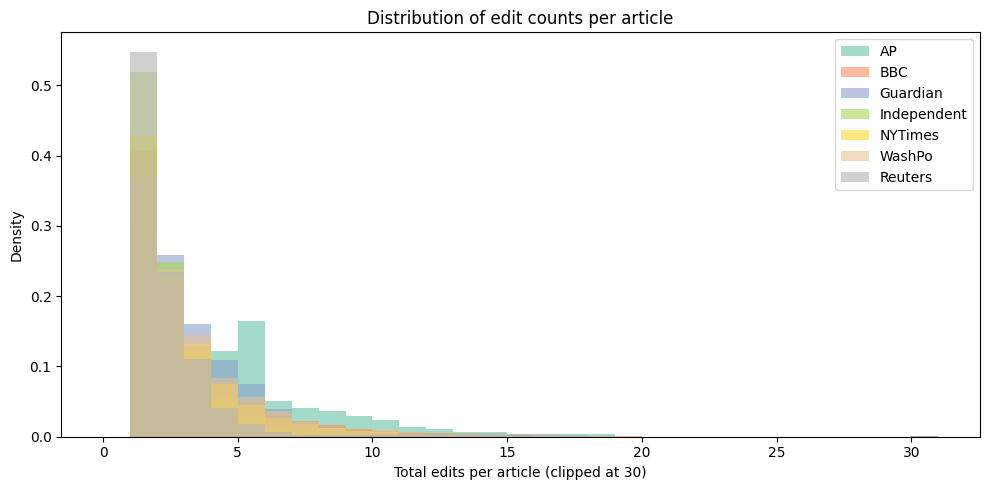

Edit count statistics per outlet:


,mean,median,p75,max
outlet,,,,
AP,4.2,4.0,5.0,21.0
BBC,2.8,2.0,3.0,151.0
Guardian,2.9,2.0,4.0,56.0
Independent,1.9,1.0,2.0,17.0
NYTimes,2.6,2.0,3.0,18.0
WashPo,2.8,2.0,3.0,17.0
Reuters,2.2,1.0,2.0,18.0


In [3]:
# Distribution of total edits per article, by outlet
fig, ax = plt.subplots(figsize=(10, 5))
for outlet in OUTLET_ORDER:
    subset = articles[articles["outlet"] == outlet]
    edits = subset["total_edits"].clip(upper=30)
    ax.hist(edits, bins=range(0, 32), alpha=0.6, label=outlet, color=OUTLET_COLORS[outlet], density=True)
ax.set_xlabel("Total edits per article (clipped at 30)")
ax.set_ylabel("Density")
ax.set_title("Distribution of edit counts per article")
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
edit_stats = articles.groupby("outlet")["total_edits"].describe()[["mean", "50%", "75%", "max"]]
edit_stats.columns = ["mean", "median", "p75", "max"]
edit_stats = edit_stats.reindex(OUTLET_ORDER)
print("Edit count statistics per outlet:")
display(edit_stats.round(1))

## 2. Edit Type Analysis

What kinds of edits do different outlets make? The `edit_type` field classifies each version pair.

In [4]:
# Load version pairs (deduplicate by composite key)
pairs = query_all("""
    SELECT DISTINCT
        article_id, news_org, from_version_id, to_version_id,
        from_version_num, to_version_num,
        delta_minutes, tokens_added, tokens_deleted, percent_text_new,
        edit_type, edit_summary, edit_confidence,
        angle_changed, angle_change_category, angle_summary, angle_confidence,
        title_jaccard_prev, title_jaccard_curr, summary_jaccard
    FROM version_pairs
""")
print(f"Total version pairs: {len(pairs):,}")
pairs["edit_type"] = pairs["edit_type"].fillna("unknown")

# Edit type distribution by outlet (normalized)
et_counts = pairs.groupby(["outlet", "edit_type"]).size().reset_index(name="count")
et_totals = et_counts.groupby("outlet")["count"].transform("sum")
et_counts["pct"] = (et_counts["count"] / et_totals * 100).round(1)

et_pivot = et_counts.pivot(index="edit_type", columns="outlet", values="pct").fillna(0)
et_pivot = et_pivot[[c for c in OUTLET_ORDER if c in et_pivot.columns]]
et_pivot = et_pivot.sort_values(et_pivot.columns[0], ascending=False)

print("\nEdit type distribution (% of pairs per outlet):")
display(et_pivot.round(1))

Total version pairs: 120,570

Edit type distribution (% of pairs per outlet):


outlet,AP,BBC,Guardian,Independent,NYTimes,WashPo,Reuters
edit_type,,,,,,,
content_update,68.4,61.0,39.0,43.5,39.1,67.1,45.6
copyedit,23.0,26.1,43.8,37.1,35.4,21.6,37.6
new_source_added,3.1,5.7,4.8,5.9,5.0,1.7,5.6
correction,2.2,0.6,1.9,0.5,0.9,0.7,0.7
source_removed,1.8,1.1,2.6,4.6,4.5,0.4,4.4
unknown,0.9,0.7,1.6,0.1,0.2,1.5,0.0
title_change,0.4,4.2,5.6,7.9,14.6,6.6,5.5
emphasis_change,0.2,0.5,0.4,0.5,0.3,0.3,0.5
other,0.1,0.0,0.2,0.1,0.0,0.0,0.0


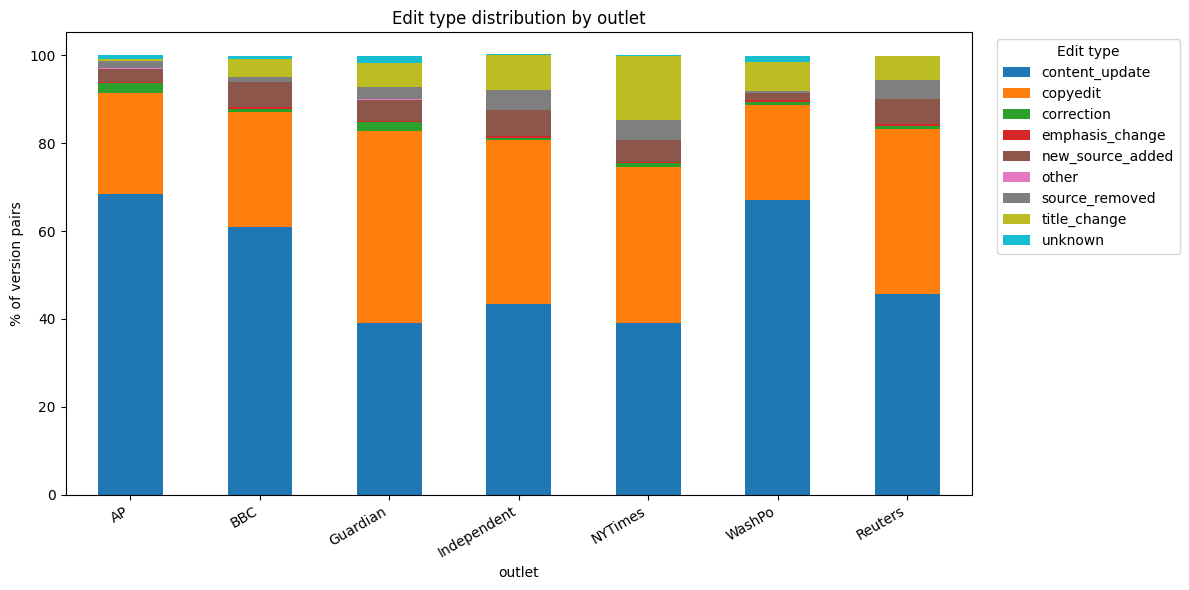

In [5]:
# Stacked bar chart of edit types by outlet
et_pct_pivot = et_counts.pivot(index="outlet", columns="edit_type", values="pct").fillna(0)
et_pct_pivot = et_pct_pivot.reindex(OUTLET_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
et_pct_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("% of version pairs")
ax.set_title("Edit type distribution by outlet")
ax.legend(title="Edit type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Angle Change Analysis

How often do outlets change the angle/framing of an article between versions?

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/3650952096.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(angle_rate.index, rotation=30, ha="right")


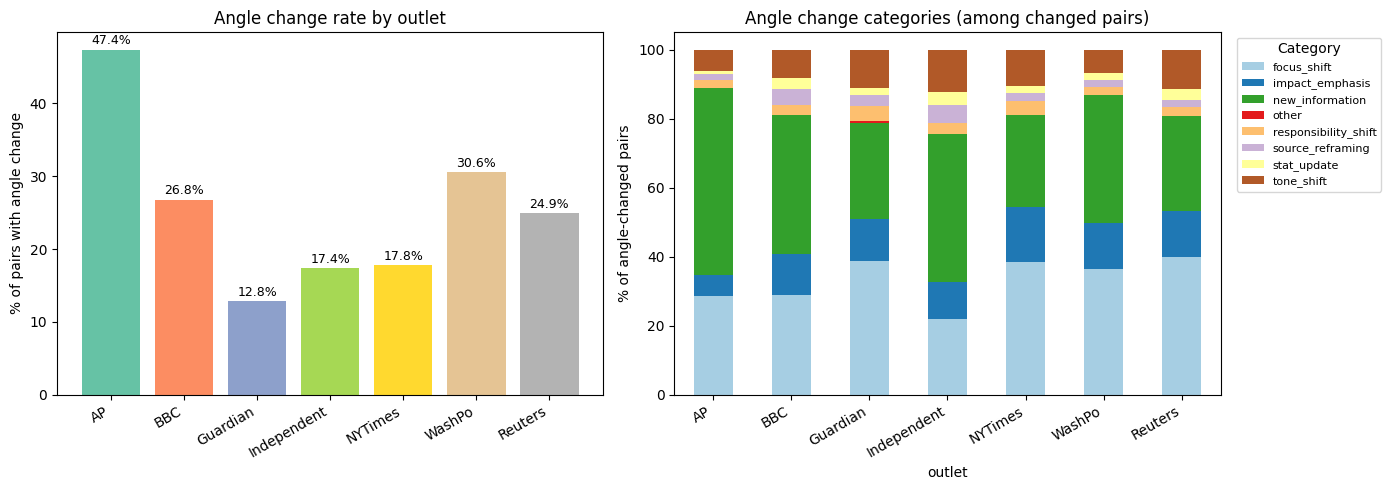


Angle change rate:


,total_pairs,angle_changed,pct_changed
outlet,,,
AP,13624,6457,47.4
BBC,40283,10795,26.8
Guardian,25309,3250,12.8
Independent,11642,2027,17.4
NYTimes,17987,3193,17.8
WashPo,2010,616,30.6
Reuters,9715,2418,24.9


In [6]:
# Angle change rate by outlet
angle_rate = pairs.groupby("outlet").agg(
    total_pairs=("angle_changed", "size"),
    angle_changed=("angle_changed", "sum"),
).reindex(OUTLET_ORDER)
angle_rate["pct_changed"] = (angle_rate["angle_changed"] / angle_rate["total_pairs"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: % of pairs with angle change
ax = axes[0]
bars = ax.bar(angle_rate.index, angle_rate["pct_changed"], 
              color=[OUTLET_COLORS[o] for o in angle_rate.index])
ax.set_ylabel("% of pairs with angle change")
ax.set_title("Angle change rate by outlet")
ax.set_xticklabels(angle_rate.index, rotation=30, ha="right")
for bar, val in zip(bars, angle_rate["pct_changed"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f"{val}%", ha="center", va="bottom", fontsize=9)

# Angle change category breakdown
pairs["angle_change_category"] = pairs["angle_change_category"].fillna("no_change")
ac_counts = pairs[pairs["angle_changed"] == 1].groupby(["outlet", "angle_change_category"]).size().reset_index(name="count")
ac_totals = ac_counts.groupby("outlet")["count"].transform("sum")
ac_counts["pct"] = (ac_counts["count"] / ac_totals * 100).round(1)
ac_pivot = ac_counts.pivot(index="outlet", columns="angle_change_category", values="pct").fillna(0)
ac_pivot = ac_pivot.reindex(OUTLET_ORDER)

ax = axes[1]
ac_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Paired")
ax.set_ylabel("% of angle-changed pairs")
ax.set_title("Angle change categories (among changed pairs)")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

print("\nAngle change rate:")
display(angle_rate)

## 4. Edit Magnitude

How much text changes between versions? Comparing tokens added/deleted and overall text churn.

Edit magnitude by outlet:


,mean_tokens_added,mean_tokens_deleted,mean_pct_new,median_pct_new
outlet,,,,
AP,279.1,185.2,0.5,0.5
BBC,211.6,36.9,0.4,0.4
Guardian,168.2,45.7,0.2,0.1
Independent,194.1,76.7,0.4,0.3
NYTimes,355.8,114.7,0.4,0.3
WashPo,281.4,82.7,0.4,0.4
Reuters,231.4,77.5,0.4,0.3


/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/754944696.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_outlet, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/754944696.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")


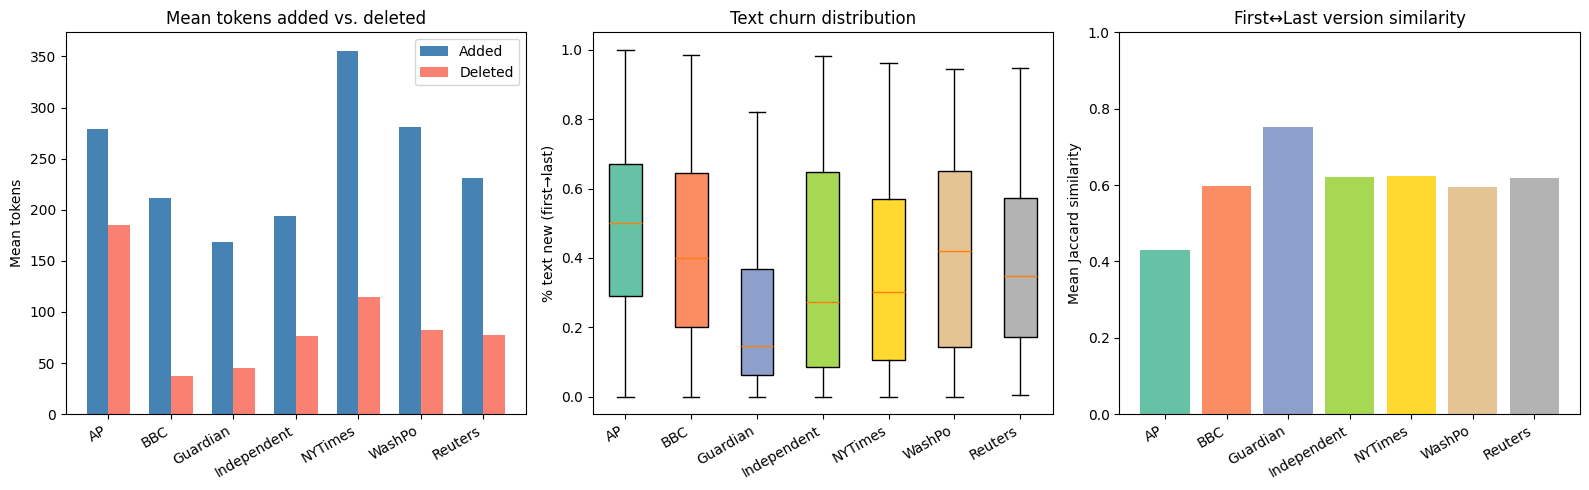

In [7]:
# Text churn metrics
magnitude = pairs.groupby("outlet").agg(
    mean_tokens_added=("tokens_added", "mean"),
    mean_tokens_deleted=("tokens_deleted", "mean"),
    mean_pct_new=("percent_text_new", "mean"),
    median_pct_new=("percent_text_new", "median"),
).reindex(OUTLET_ORDER).round(1)

print("Edit magnitude by outlet:")
display(magnitude)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tokens added vs deleted
ax = axes[0]
x = np.arange(len(OUTLET_ORDER))
w = 0.35
ax.bar(x - w/2, magnitude["mean_tokens_added"], w, label="Added", color="steelblue")
ax.bar(x + w/2, magnitude["mean_tokens_deleted"], w, label="Deleted", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")
ax.set_ylabel("Mean tokens")
ax.set_title("Mean tokens added vs. deleted")
ax.legend()

# Percent text new distribution (box plot)
ax = axes[1]
data_by_outlet = [pairs[pairs["outlet"] == o]["percent_text_new"].dropna().clip(upper=1) for o in OUTLET_ORDER]
bp = ax.boxplot(data_by_outlet, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("% text new (first→last)")
ax.set_title("Text churn distribution")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# Summary jaccard similarity (how similar are first and last versions?)
ax = axes[2]
jaccard_means = pairs.groupby("outlet")["summary_jaccard"].mean().reindex(OUTLET_ORDER)
bars = ax.bar(OUTLET_ORDER, jaccard_means, color=[OUTLET_COLORS[o] for o in OUTLET_ORDER])
ax.set_ylabel("Mean Jaccard similarity")
ax.set_title("First↔Last version similarity")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Temporal Editing Patterns

How quickly do outlets revise their articles? Distribution of time between first and last version.

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/3529185414.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)


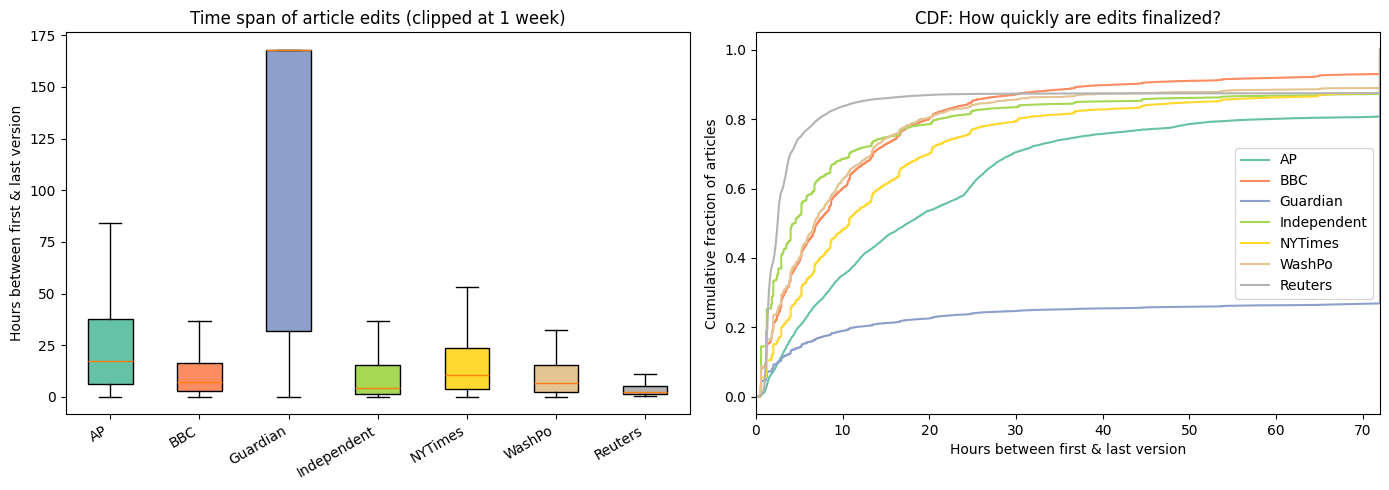

Time span statistics (hours):


,mean_hours,median_hours
outlet,,
AP,309.4,17.5
BBC,64.6,7.1
Guardian,1997.5,854.2
Independent,321.7,4.4
NYTimes,176.2,10.8
WashPo,362.0,6.8
Reuters,405.3,2.5


In [8]:
# Time between first and last versions
pairs["delta_hours"] = pairs["delta_minutes"] / 60
pairs["delta_days"] = pairs["delta_minutes"] / 1440

time_stats = pairs.groupby("outlet")["delta_hours"].agg(["mean", "median"]).reindex(OUTLET_ORDER).round(1)
time_stats.columns = ["mean_hours", "median_hours"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of delta hours (clipped)
ax = axes[0]
data = [pairs[pairs["outlet"] == o]["delta_hours"].dropna().clip(upper=168) for o in OUTLET_ORDER]  # clip at 1 week
bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("Hours between first & last version")
ax.set_title("Time span of article edits (clipped at 1 week)")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# CDF of edit time spans
ax = axes[1]
for outlet in OUTLET_ORDER:
    hours = pairs[pairs["outlet"] == outlet]["delta_hours"].dropna().sort_values()
    if len(hours) == 0:
        continue
    cdf = np.arange(1, len(hours) + 1) / len(hours)
    ax.plot(hours.clip(upper=72), cdf, label=outlet, color=OUTLET_COLORS[outlet])
ax.set_xlabel("Hours between first & last version")
ax.set_ylabel("Cumulative fraction of articles")
ax.set_title("CDF: How quickly are edits finalized?")
ax.legend()
ax.set_xlim(0, 72)

plt.tight_layout()
plt.show()

print("Time span statistics (hours):")
display(time_stats)

## 6. Source Dynamics

How do sourcing practices differ across outlets? Source types, anonymity, speech styles, and how sources evolve between versions.

Total source mention rows: 822,252


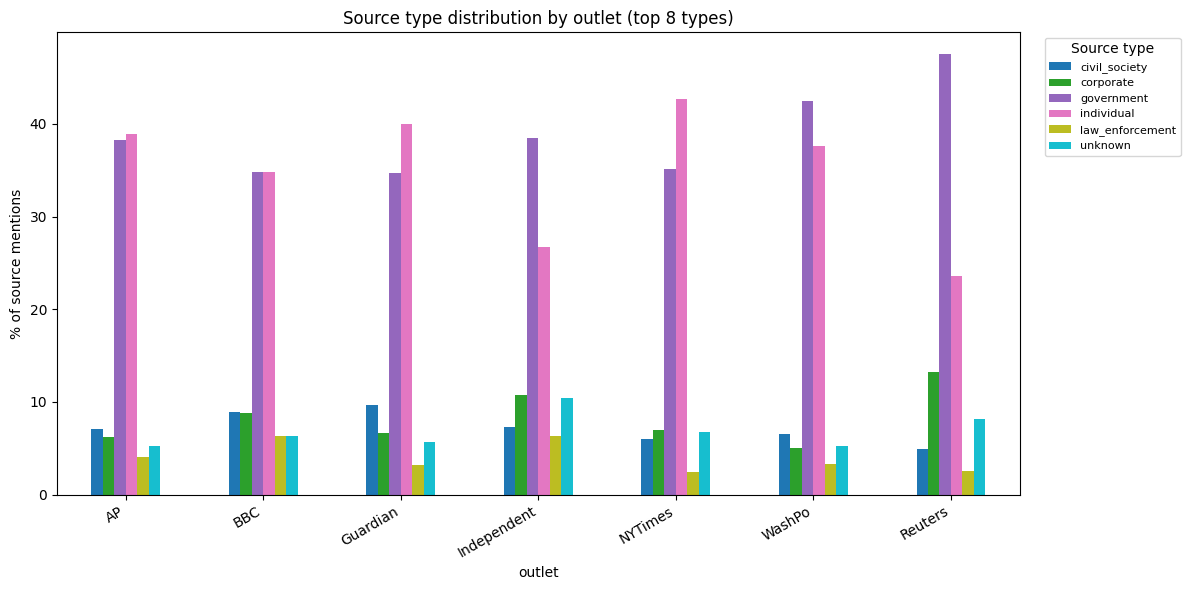


Source type distribution (%):


source_type,civil_society,corporate,government,individual,law_enforcement,unknown
outlet,,,,,,
AP,7.1,6.2,38.3,38.9,4.1,5.3
BBC,8.9,8.8,34.8,34.8,6.3,6.3
Guardian,9.7,6.7,34.7,40.0,3.2,5.7
Independent,7.3,10.8,38.5,26.7,6.3,10.4
NYTimes,6.0,7.0,35.1,42.7,2.4,6.8
WashPo,6.5,5.0,42.5,37.6,3.3,5.2
Reuters,4.9,13.2,47.5,23.6,2.6,8.2


In [9]:
# Source mentions - deduplicate identical rows
sources = query_all("""
    SELECT DISTINCT
        article_id, news_org, version_id, source_id_within_article,
        source_type, speech_style, is_anonymous, is_in_lede, is_in_title,
        centrality, confidence
    FROM source_mentions
""")
print(f"Total source mention rows: {len(sources):,}")

# Source type distribution by outlet
st_counts = sources.groupby(["outlet", "source_type"]).size().reset_index(name="count")
st_totals = st_counts.groupby("outlet")["count"].transform("sum")
st_counts["pct"] = (st_counts["count"] / st_totals * 100).round(1)

# Top source types
top_types = st_counts.groupby("source_type")["count"].sum().nlargest(8).index
st_top = st_counts[st_counts["source_type"].isin(top_types)]
st_pivot = st_top.pivot(index="outlet", columns="source_type", values="pct").fillna(0)
st_pivot = st_pivot.reindex(OUTLET_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
st_pivot.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_ylabel("% of source mentions")
ax.set_title("Source type distribution by outlet (top 8 types)")
ax.legend(title="Source type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSource type distribution (%):")
display(st_pivot.round(1))

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/3488337477.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")


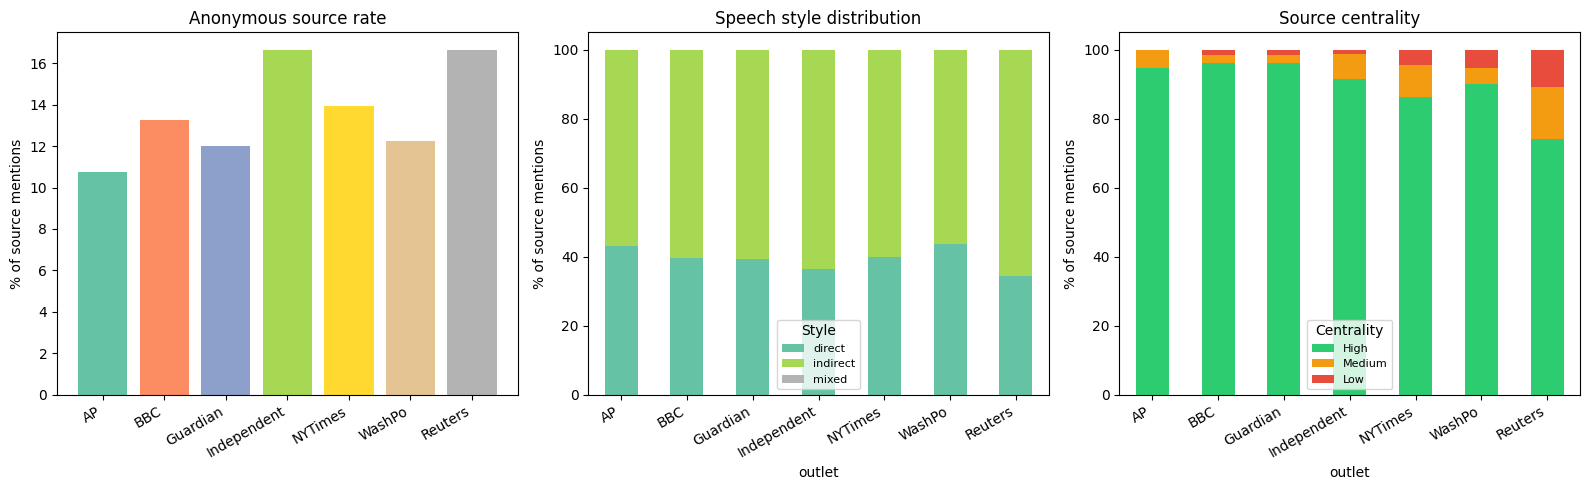

In [10]:
# Anonymous source usage & speech style
anon_rate = sources.groupby("outlet")["is_anonymous"].mean().reindex(OUTLET_ORDER) * 100
lede_rate = sources.groupby("outlet")["is_in_lede"].mean().reindex(OUTLET_ORDER) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Anonymous source rate
ax = axes[0]
bars = ax.bar(OUTLET_ORDER, anon_rate, color=[OUTLET_COLORS[o] for o in OUTLET_ORDER])
ax.set_ylabel("% of source mentions")
ax.set_title("Anonymous source rate")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# Speech style breakdown
ss_counts = sources.groupby(["outlet", "speech_style"]).size().reset_index(name="count")
ss_totals = ss_counts.groupby("outlet")["count"].transform("sum")
ss_counts["pct"] = (ss_counts["count"] / ss_totals * 100)
ss_pivot = ss_counts.pivot(index="outlet", columns="speech_style", values="pct").fillna(0)
ss_pivot = ss_pivot.reindex(OUTLET_ORDER)

ax = axes[1]
ss_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_ylabel("% of source mentions")
ax.set_title("Speech style distribution")
ax.legend(title="Style", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

# Centrality distribution
cent_counts = sources.groupby(["outlet", "centrality"]).size().reset_index(name="count")
cent_totals = cent_counts.groupby("outlet")["count"].transform("sum")
cent_counts["pct"] = (cent_counts["count"] / cent_totals * 100)
cent_pivot = cent_counts.pivot(index="outlet", columns="centrality", values="pct").fillna(0)
cent_pivot = cent_pivot.reindex(OUTLET_ORDER)
# Reorder columns if possible
for order in [["High", "Medium", "Low"]]:
    cols = [c for c in order if c in cent_pivot.columns] + [c for c in cent_pivot.columns if c not in order]
    cent_pivot = cent_pivot[cols]

ax = axes[2]
cent_pivot.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"][:len(cent_pivot.columns)])
ax.set_ylabel("% of source mentions")
ax.set_title("Source centrality")
ax.legend(title="Centrality", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 7. Version-Level Metrics

Hedge density, institutional source share, and anonymous source share across versions and outlets.

Total version metric rows: 261,684


/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/829134573.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/829134573.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/829134573.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)


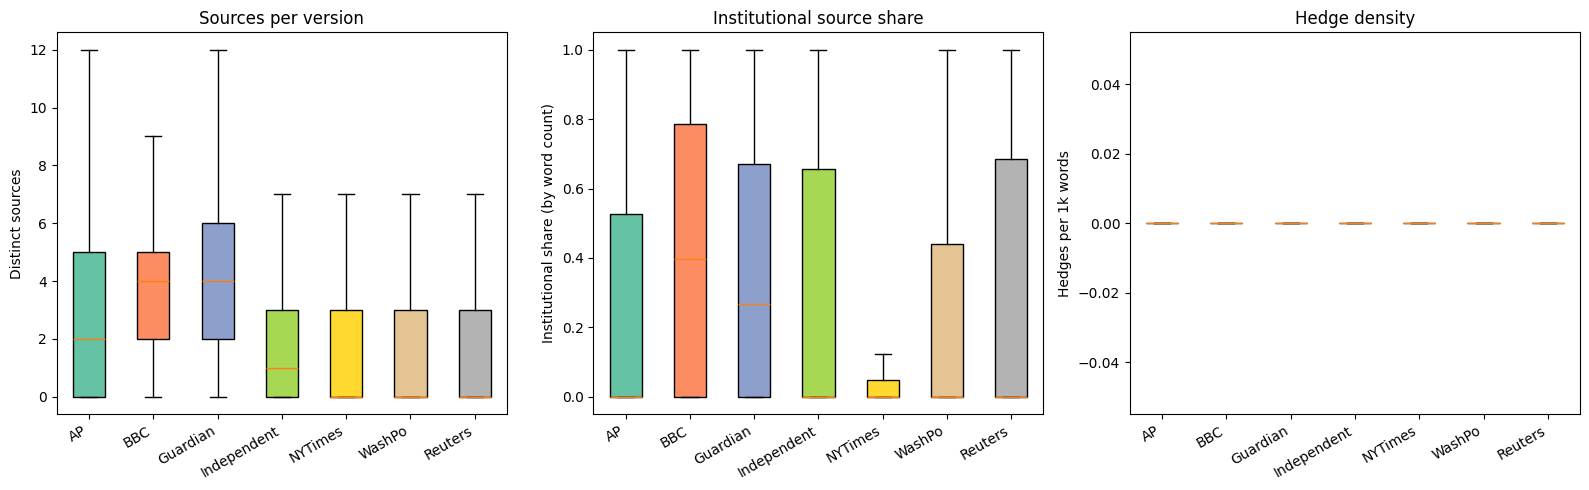


Version metrics summary:


,mean_sources,mean_inst_share,mean_anon_share,mean_hedge
outlet,,,,
AP,2.647,0.262,0.056,0.000
BBC,3.823,0.434,0.106,0.013
Guardian,4.095,0.362,0.094,0.008
Independent,1.781,0.301,0.082,0.070
NYTimes,1.436,0.149,0.047,0.022
WashPo,1.915,0.229,0.056,0.187
Reuters,1.711,0.298,0.078,0.120


In [11]:
# Version metrics
vm = query_all("""
    SELECT version_id, article_id, news_org,
           distinct_sources, institutional_share_words,
           anonymous_source_share_words, hedge_density_per_1k
    FROM version_metrics
""")
print(f"Total version metric rows: {len(vm):,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distinct sources per version
ax = axes[0]
data = [vm[vm["outlet"] == o]["distinct_sources"].dropna() for o in OUTLET_ORDER]
bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("Distinct sources")
ax.set_title("Sources per version")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# Institutional share
ax = axes[1]
data = [vm[vm["outlet"] == o]["institutional_share_words"].dropna() for o in OUTLET_ORDER]
bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("Institutional share (by word count)")
ax.set_title("Institutional source share")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# Hedge density
ax = axes[2]
data = [vm[vm["outlet"] == o]["hedge_density_per_1k"].dropna().clip(upper=20) for o in OUTLET_ORDER]
bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("Hedges per 1k words")
ax.set_title("Hedge density")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

plt.tight_layout()
plt.show()

# Summary table
vm_summary = vm.groupby("outlet").agg(
    mean_sources=("distinct_sources", "mean"),
    mean_inst_share=("institutional_share_words", "mean"),
    mean_anon_share=("anonymous_source_share_words", "mean"),
    mean_hedge=("hedge_density_per_1k", "mean"),
).reindex(OUTLET_ORDER).round(3)
print("\nVersion metrics summary:")
display(vm_summary)

## 8. Edit Type vs. Angle Change Interaction

Are certain edit types more likely to produce angle changes?

Angle change rate by edit type (all outlets):


,pair_count,% with angle change
edit_type,,
content_update,61665,40.1
copyedit,39517,0.1
title_change,7364,36.3
new_source_added,6112,13.5
source_removed,3137,2.3
correction,1329,10.1
unknown,872,7.5
emphasis_change,495,46.9
other,79,32.9


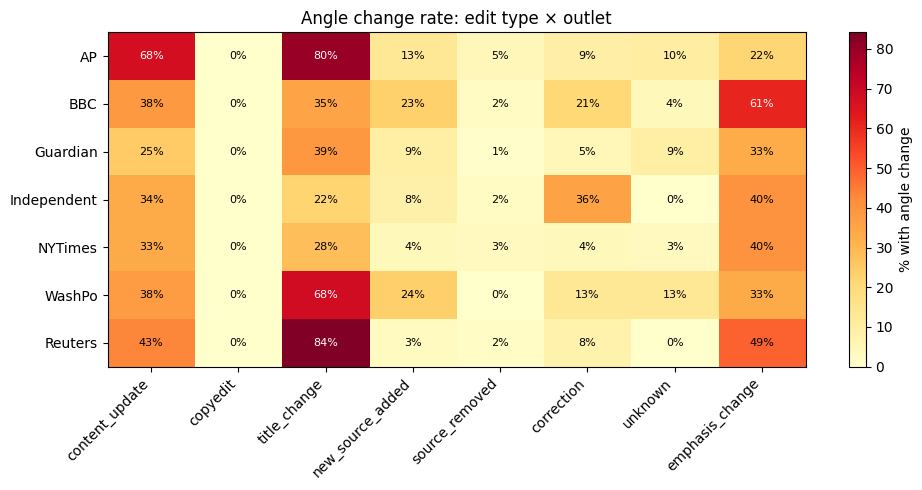

In [12]:
# Cross-tab: edit_type × angle_changed
ct = pairs.groupby("edit_type").agg(
    n=("angle_changed", "size"),
    angle_pct=("angle_changed", "mean"),
).sort_values("n", ascending=False)
ct["angle_pct"] = (ct["angle_pct"] * 100).round(1)
ct = ct.rename(columns={"n": "pair_count", "angle_pct": "% with angle change"})

print("Angle change rate by edit type (all outlets):")
display(ct)

# Heatmap: edit_type × outlet → angle change rate
heat_data = pairs.groupby(["outlet", "edit_type"])["angle_changed"].mean().unstack(fill_value=0) * 100
# Keep only edit types with > 100 total pairs
type_counts = pairs["edit_type"].value_counts()
keep_types = type_counts[type_counts > 100].index
heat_data = heat_data[[c for c in keep_types if c in heat_data.columns]]
heat_data = heat_data.reindex(OUTLET_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat_data.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels(heat_data.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index)
# Annotate cells
for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        val = heat_data.iloc[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if val > 50 else "black")
plt.colorbar(im, ax=ax, label="% with angle change")
ax.set_title("Angle change rate: edit type × outlet")
plt.tight_layout()
plt.show()

## 9. Title Stability

Do outlets change their headlines? Comparing title Jaccard similarity between first and last versions.

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/4195263822.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/4195263822.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")


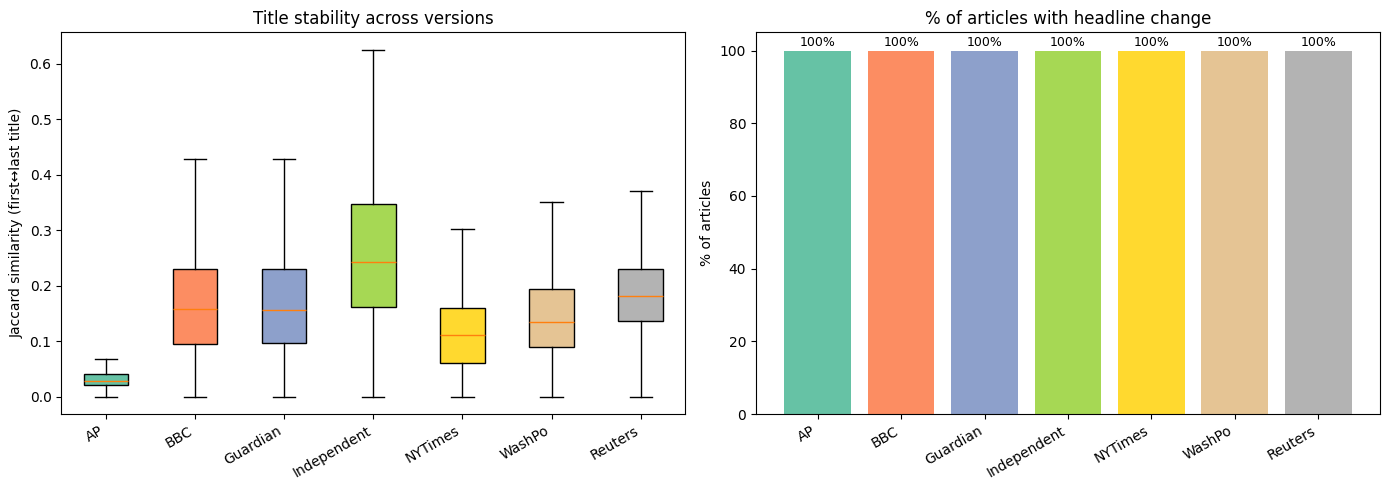

In [13]:
# Title jaccard: how much do headlines change?
# title_jaccard_curr measures overlap between first title and final title
title_jacc = pairs.dropna(subset=["title_jaccard_curr"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of title jaccard
ax = axes[0]
data = [title_jacc[title_jacc["outlet"] == o]["title_jaccard_curr"].dropna() for o in OUTLET_ORDER]
bp = ax.boxplot(data, labels=OUTLET_ORDER, patch_artist=True, showfliers=False)
for patch, o in zip(bp["boxes"], OUTLET_ORDER):
    patch.set_facecolor(OUTLET_COLORS[o])
ax.set_ylabel("Jaccard similarity (first↔last title)")
ax.set_title("Title stability across versions")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")

# % of articles with title change (jaccard < 1.0)
ax = axes[1]
title_changed = title_jacc.groupby("outlet").apply(
    lambda g: (g["title_jaccard_curr"] < 0.99).mean() * 100
).reindex(OUTLET_ORDER)
bars = ax.bar(OUTLET_ORDER, title_changed, color=[OUTLET_COLORS[o] for o in OUTLET_ORDER])
ax.set_ylabel("% of articles")
ax.set_title("% of articles with headline change")
ax.set_xticklabels(OUTLET_ORDER, rotation=30, ha="right")
for bar, val in zip(bars, title_changed):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 10. Source Lifecycle (sources_agg)

How do sources appear and disappear across article versions? Do some outlets retain sources more consistently?

Sources_agg rows: 1,297


/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/1834047597.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_filtered, labels=labels_filtered, patch_artist=True, showfliers=False)
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/1834047597.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(disappeared.index, rotation=30, ha="right")
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_83947/1834047597.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(doubted.index, rotation=30, ha="right")


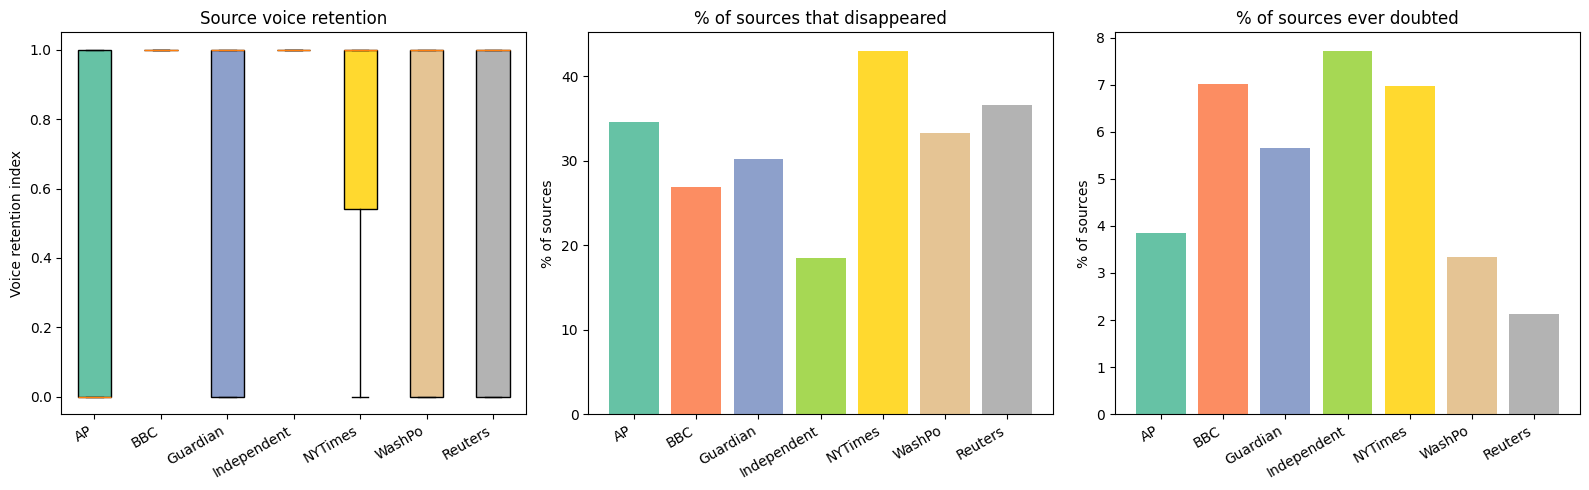

In [14]:
# Sources_agg: lifecycle metrics
sagg = query_all("""
    SELECT article_id, news_org, source_id_within_article, source_canonical, source_type,
           first_seen_version, last_seen_version, num_mentions_total, num_versions_present,
           total_attributed_words, voice_retention_index, mean_prominence,
           doubted_any, deemphasized_any, disappeared_any
    FROM sources_agg
""")
print(f"Sources_agg rows: {len(sagg):,}")

if len(sagg) > 50:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Voice retention index
    ax = axes[0]
    data = [sagg[sagg["outlet"] == o]["voice_retention_index"].dropna() for o in OUTLET_ORDER]
    data_filtered = [d for d in data if len(d) > 0]
    labels_filtered = [o for o, d in zip(OUTLET_ORDER, data) if len(d) > 0]
    if data_filtered:
        bp = ax.boxplot(data_filtered, labels=labels_filtered, patch_artist=True, showfliers=False)
        for patch, o in zip(bp["boxes"], labels_filtered):
            patch.set_facecolor(OUTLET_COLORS[o])
    ax.set_ylabel("Voice retention index")
    ax.set_title("Source voice retention")
    ax.set_xticklabels(labels_filtered, rotation=30, ha="right")

    # Disappeared rate
    ax = axes[1]
    disappeared = sagg.groupby("outlet")["disappeared_any"].mean().reindex(OUTLET_ORDER).dropna() * 100
    if not disappeared.empty:
        bars = ax.bar(disappeared.index, disappeared.values,
                      color=[OUTLET_COLORS[o] for o in disappeared.index])
        ax.set_ylabel("% of sources")
        ax.set_title("% of sources that disappeared")
        ax.set_xticklabels(disappeared.index, rotation=30, ha="right")

    # Doubted rate
    ax = axes[2]
    doubted = sagg.groupby("outlet")["doubted_any"].mean().reindex(OUTLET_ORDER).dropna() * 100
    if not doubted.empty:
        bars = ax.bar(doubted.index, doubted.values,
                      color=[OUTLET_COLORS[o] for o in doubted.index])
        ax.set_ylabel("% of sources")
        ax.set_title("% of sources ever doubted")
        ax.set_xticklabels(doubted.index, rotation=30, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient sources_agg data for visualization.")

## 11. Edit Confidence & LLM Agreement

How confident is the LLM in its edit type and angle change classifications?

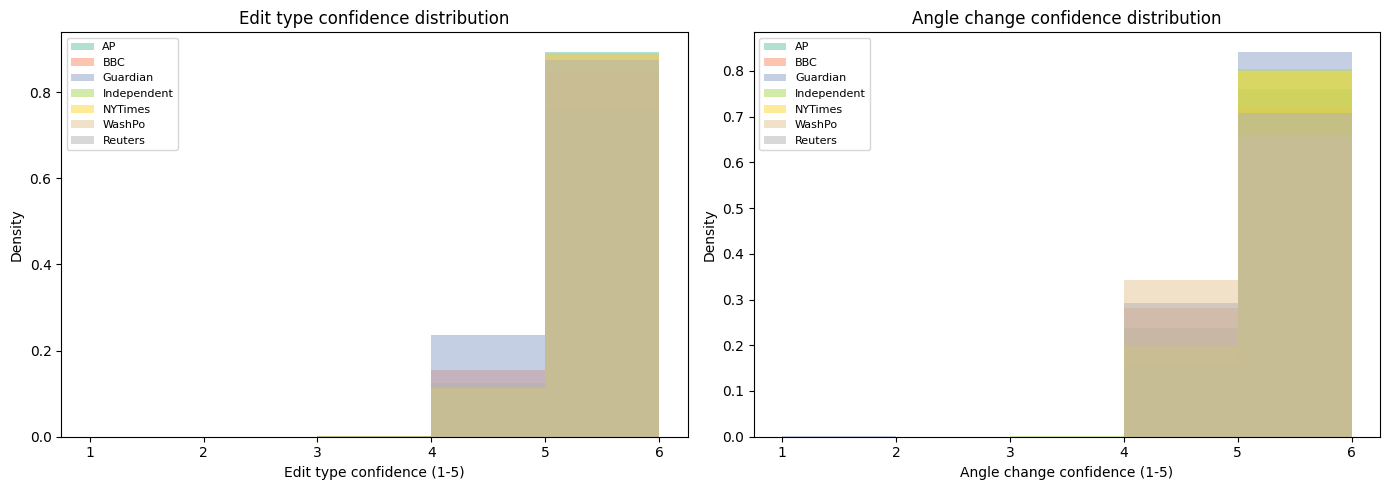

Mean confidence scores:


,mean_edit_conf,mean_angle_conf
outlet,,
AP,4.89,4.76
BBC,4.84,4.72
Guardian,4.76,4.84
Independent,4.88,4.80
NYTimes,4.88,4.80
WashPo,4.89,4.66
Reuters,4.87,4.71


In [15]:
# Confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for outlet in OUTLET_ORDER:
    subset = pairs[pairs["outlet"] == outlet]["edit_confidence"].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=range(1, 7), alpha=0.5, label=outlet, density=True, color=OUTLET_COLORS[outlet])
ax.set_xlabel("Edit type confidence (1-5)")
ax.set_ylabel("Density")
ax.set_title("Edit type confidence distribution")
ax.legend(fontsize=8)

ax = axes[1]
for outlet in OUTLET_ORDER:
    subset = pairs[pairs["outlet"] == outlet]["angle_confidence"].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=range(1, 7), alpha=0.5, label=outlet, density=True, color=OUTLET_COLORS[outlet])
ax.set_xlabel("Angle change confidence (1-5)")
ax.set_ylabel("Density")
ax.set_title("Angle change confidence distribution")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Mean confidence by outlet
conf = pairs.groupby("outlet").agg(
    mean_edit_conf=("edit_confidence", "mean"),
    mean_angle_conf=("angle_confidence", "mean"),
).reindex(OUTLET_ORDER).round(2)
print("Mean confidence scores:")
display(conf)

## 12. Composite Dashboard

Key metrics side-by-side for cross-outlet comparison.

In [16]:
# Build composite summary table
dashboard = pd.DataFrame(index=OUTLET_ORDER)
dashboard.index.name = "Outlet"

# From articles
a_stats = articles.groupby("outlet").agg(
    articles=("article_id", "count"),
    mean_edits=("total_edits", "mean"),
)
dashboard["articles"] = a_stats["articles"]
dashboard["mean_edits"] = a_stats["mean_edits"].round(1)

# From pairs
p_stats = pairs.groupby("outlet").agg(
    mean_pct_new=("percent_text_new", "mean"),
    angle_rate=("angle_changed", "mean"),
    mean_delta_h=("delta_hours", "median"),
    mean_jaccard=("summary_jaccard", "mean"),
)
dashboard["median_edit_span_hrs"] = p_stats["mean_delta_h"].round(1)
dashboard["mean_pct_text_new"] = (p_stats["mean_pct_new"] * 100).round(1)
dashboard["angle_change_%"] = (p_stats["angle_rate"] * 100).round(1)
dashboard["mean_body_jaccard"] = p_stats["mean_jaccard"].round(3)

# From version metrics
vm_stats = vm.groupby("outlet").agg(
    mean_sources=("distinct_sources", "mean"),
    anon_share=("anonymous_source_share_words", "mean"),
    hedge_density=("hedge_density_per_1k", "mean"),
)
dashboard["mean_sources_per_v"] = vm_stats["mean_sources"].round(1)
dashboard["anon_source_%"] = (vm_stats["anon_share"] * 100).round(1)
dashboard["hedge_per_1k"] = vm_stats["hedge_density"].round(2)

# From source mentions
dashboard["anon_mention_%"] = (sources.groupby("outlet")["is_anonymous"].mean() * 100).round(1)

# Top edit type per outlet
top_edit = pairs.groupby("outlet")["edit_type"].agg(lambda x: x.value_counts().index[0])
dashboard["most_common_edit"] = top_edit

dashboard = dashboard.reindex(OUTLET_ORDER)
print("Cross-outlet dashboard:")
display(dashboard.T)

Cross-outlet dashboard:


Outlet,AP,BBC,Guardian,Independent,NYTimes,WashPo,Reuters
articles,12483,40226,25324,11692,17993,2041,9675
mean_edits,4.2,2.8,2.9,1.9,2.6,2.8,2.2
median_edit_span_hrs,17.5,7.1,854.2,4.4,10.8,6.8,2.5
mean_pct_text_new,48.4,42.6,24.3,36.2,35.2,42.0,38.8
angle_change_%,47.4,26.8,12.8,17.4,17.8,30.6,24.9
mean_body_jaccard,0.429,0.598,0.752,0.62,0.623,0.595,0.619
mean_sources_per_v,2.6,3.8,4.1,1.8,1.4,1.9,1.7
anon_source_%,5.6,10.6,9.4,8.2,4.7,5.6,7.8
hedge_per_1k,0.0,0.01,0.01,0.07,0.02,0.19,0.12
anon_mention_%,10.7,13.3,12.0,16.7,13.9,12.3,16.6
